<a href="https://colab.research.google.com/github/d1seternal/ML_X5_tech/blob/main/ML_X5_tech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import re
import time
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import HuberRegressor

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_raw = pd.read_csv('/content/drive/MyDrive/train_2.csv')

In [4]:
print(df_raw.shape)
df_raw.head()

(485082, 24)


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,...,"Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74209339.11


In [21]:
info = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'non_null': df_raw.notnull().sum(),
    'null': df_raw.isnull().sum(),
    'null_%': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'nunique': df_raw.nunique()
})
print(info.to_string())

                                           dtype  non_null  null  null_%  nunique
new_id                                     int64    485082     0     0.0    18657
Год                                        int64    485082     0     0.0        3
Месяц                                      int64    485082     0     0.0       12
Среднее_количество_промо_товаров_в_чеке  float64    485082     0     0.0      279
Среднее_количество_товаров_в_чеке        float64    485082     0     0.0      998
Среднее_количество_отмен                 float64    485082     0     0.0     2792
Рабочие_часы_в_день                      float64    485082     0     0.0       34
Дата_открытия_категориальный              object    485082     0     0.0        3
Торговая_площадь_категориальный           object    485082     0     0.0        4
Населенный_пункт                          object    485082     0     0.0     3270
Регион                                    object    485082     0     0.0       67
Численность_насе

In [22]:
num_cols = df_raw.select_dtypes(include='number').columns.tolist()
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()

print("=== Числовые признаки ===")
display(df_raw[num_cols].describe().T.round(2))

print("\n=== Категориальные признаки ===")
for c in cat_cols:
    print(f"\n{c}: {df_raw[c].nunique()} уникальных")
    print(df_raw[c].value_counts().head(10))

=== Числовые признаки ===


,count,mean,std,min,25%,50%,75%,max
new_id,485082.0,10881.24,6265.30,0.00,5455.00,10893.00,1.630800e+04,2.174500e+04
Год,485082.0,2023.62,0.62,2023.00,2023.00,2024.00,2.024000e+03,2.025000e+03
Месяц,485082.0,6.12,3.58,1.00,3.00,6.00,9.000000e+00,1.200000e+01
Среднее_количество_промо_товаров_в_чеке,485082.0,0.96,0.26,-0.00,0.77,0.92,1.110000e+00,3.530000e+00
Среднее_количество_товаров_в_чеке,485082.0,5.28,1.05,1.65,4.55,5.13,5.850000e+00,2.349000e+01
Среднее_количество_отмен,485082.0,273.60,350.63,-0.00,73.00,137.00,2.890000e+02,2.250700e+04
Рабочие_часы_в_день,485082.0,14.46,3.13,3.00,12.00,14.00,1.600000e+01,3.600000e+01
Численность_населения,485082.0,1197302.96,3028826.78,0.00,17895.00,130024.00,7.409570e+05,1.653157e+07
Количество_домохозяйств,485082.0,3588.31,2933.56,0.00,953.00,3110.00,5.526000e+03,2.473300e+04
Трафик_пеший_в_час,485082.0,132.95,80.69,0.00,88.00,123.00,1.660000e+02,1.119000e+03



=== Категориальные признаки ===

Дата_открытия_категориальный: 3 уникальных
Дата_открытия_категориальный
Средний по возрасту    347750
Новый                  113542
Открыт давно            23790
Name: count, dtype: int64

Торговая_площадь_категориальный: 4 уникальных
Торговая_площадь_категориальный
Средний          270972
Большой          100854
Маленький        100646
Очень большой     12610
Name: count, dtype: int64

Населенный_пункт: 3270 уникальных
Населенный_пункт
Москва г             33228
Санкт-Петербург г    12948
Казань г              8918
Самара г              7878
Нижний Новгород г     6760
Екатеринбург г        6084
Пермь г               5772
Челябинск г           5460
Воронеж г             5434
Краснодар г           5330
Name: count, dtype: int64

Регион: 67 уникальных
Регион
Московская обл        46384
Москва г              33228
Краснодарский край    23452
Татарстан Респ        20878
Ростовская обл        18876
Свердловская обл      17732
Нижегородская обл     16770
Сам

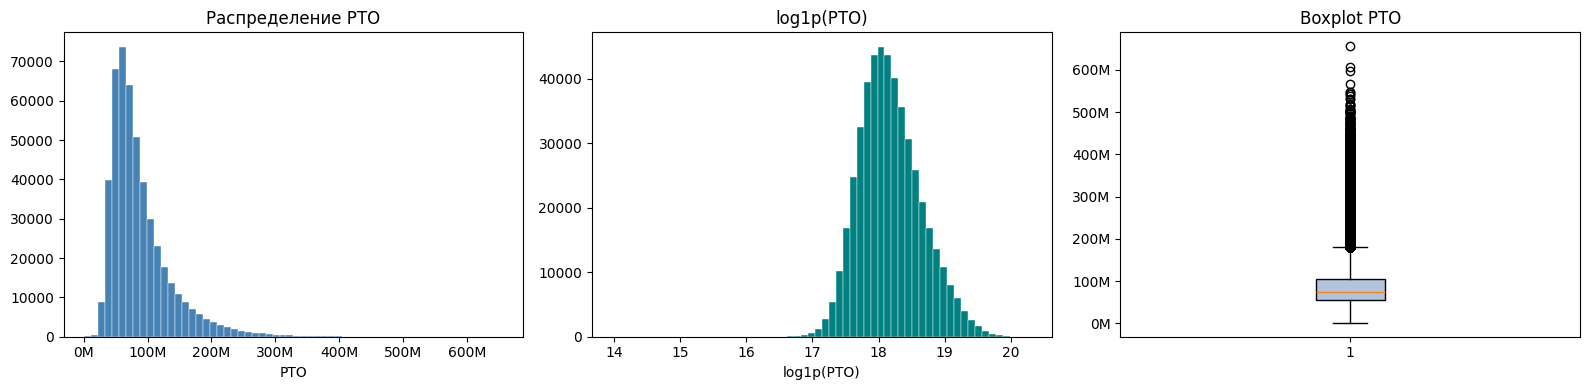

Среднее: 88,534,799
Медиана: 75,210,938
Std: 48,248,998
Skewness: 1.986
Kurtosis: 5.919
Выбросы (1%-99%): 9702 (2.00%)


In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
target = 'РТО'

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Гистограмма
axes[0].hist(df_raw[target], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Распределение РТО')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_xlabel('РТО')

# Log-трансформация
axes[1].hist(np.log1p(df_raw[target]), bins=60, color='teal', edgecolor='white', linewidth=0.3)
axes[1].set_title('log1p(РТО)')
axes[1].set_xlabel('log1p(РТО)')

# Boxplot
axes[2].boxplot(df_raw[target], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[2].set_title('Boxplot РТО')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

print(f"Среднее: {df_raw[target].mean():,.0f}")
print(f"Медиана: {df_raw[target].median():,.0f}")
print(f"Std: {df_raw[target].std():,.0f}")
print(f"Skewness: {df_raw[target].skew():.3f}")
print(f"Kurtosis: {df_raw[target].kurt():.3f}")
q1, q3 = df_raw[target].quantile([0.01, 0.99])
outliers = ((df_raw[target] < q1) | (df_raw[target] > q3)).sum()
print(f"Выбросы (1%-99%): {outliers} ({outliers/len(df_raw)*100:.2f}%)")

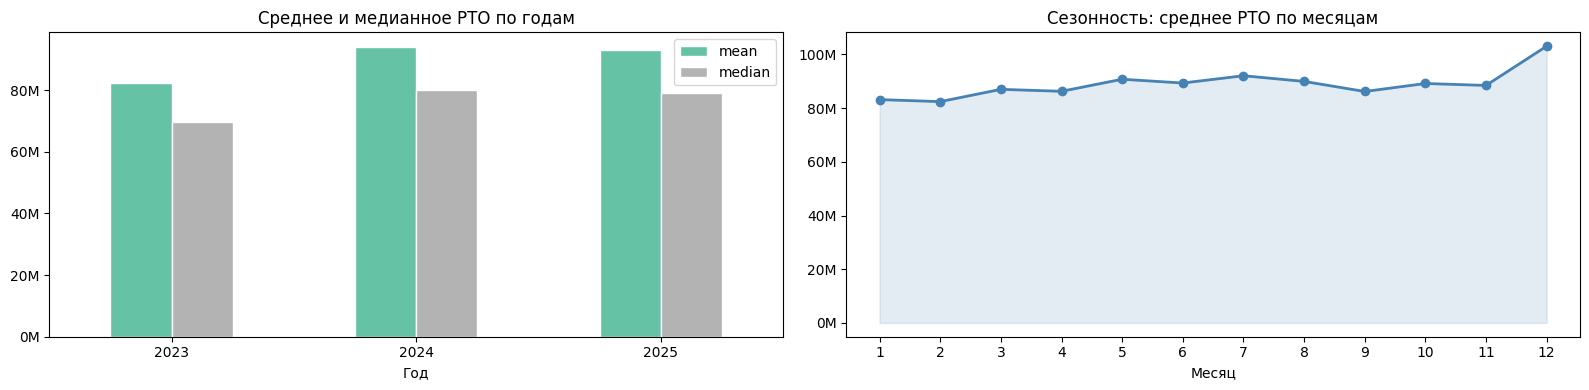

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# По годам
year_stats = df_raw.groupby('Год')['РТО'].agg(['mean', 'median'])
year_stats.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Среднее и медианное РТО по годам')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_xlabel('Год')
axes[0].tick_params(axis='x', rotation=0)

# Сезонность (по месяцам)
month_mean = df_raw.groupby('Месяц')['РТО'].mean()
axes[1].plot(month_mean.index, month_mean.values, marker='o', color='steelblue', linewidth=2)
axes[1].fill_between(month_mean.index, month_mean.values, alpha=0.15, color='steelblue')
axes[1].set_title('Сезонность: среднее РТО по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

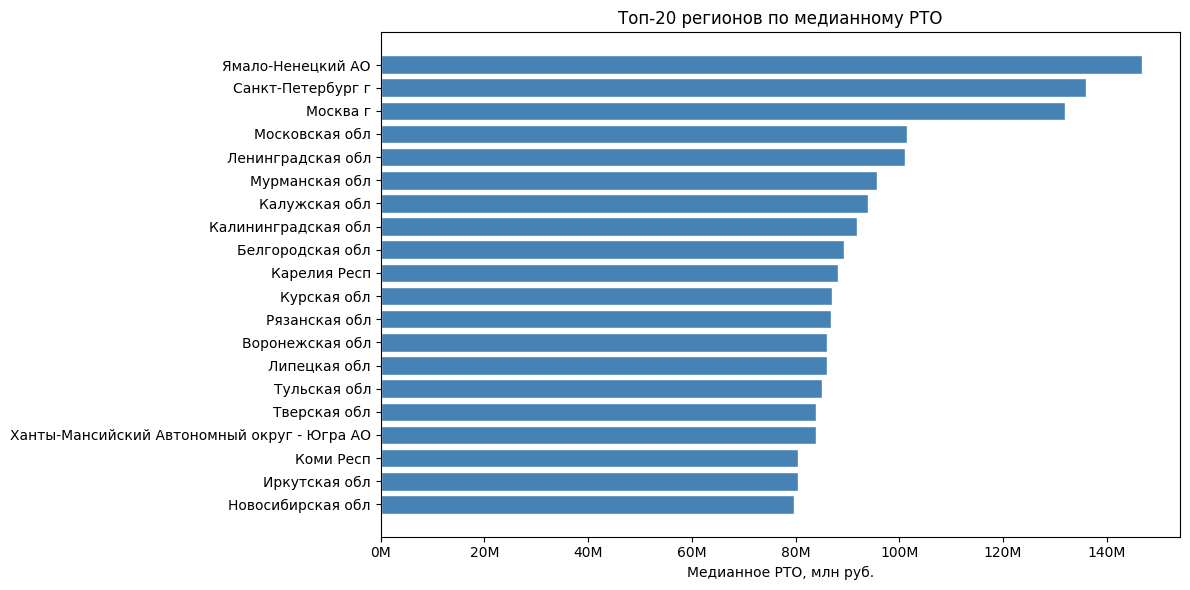

,median,count,mean
Регион,,,
Ямало-Ненецкий АО,146804642.0,1404,151735851.0
Санкт-Петербург г,135967826.0,12948,152871477.0
Москва г,131952824.0,33228,146017625.0
Московская обл,101550071.0,46384,114828437.0
Ленинградская обл,101115955.0,9750,115250934.0
Мурманская обл,95803260.0,3796,105083965.0
Калужская обл,93986205.0,5902,102649298.0
Калининградская обл,91912026.0,1248,98026184.0
Белгородская обл,89258678.0,5642,97849869.0


In [26]:
top_regions = (df_raw.groupby('Регион')['РТО']
               .agg(median='median', count='count', mean='mean')
               .sort_values('median', ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_regions.index[::-1], top_regions['median'][::-1] / 1e6,
               color='steelblue', edgecolor='white')
ax.set_xlabel('Медианное РТО, млн руб.')
ax.set_title('Топ-20 регионов по медианному РТО')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

display(top_regions.round(0))

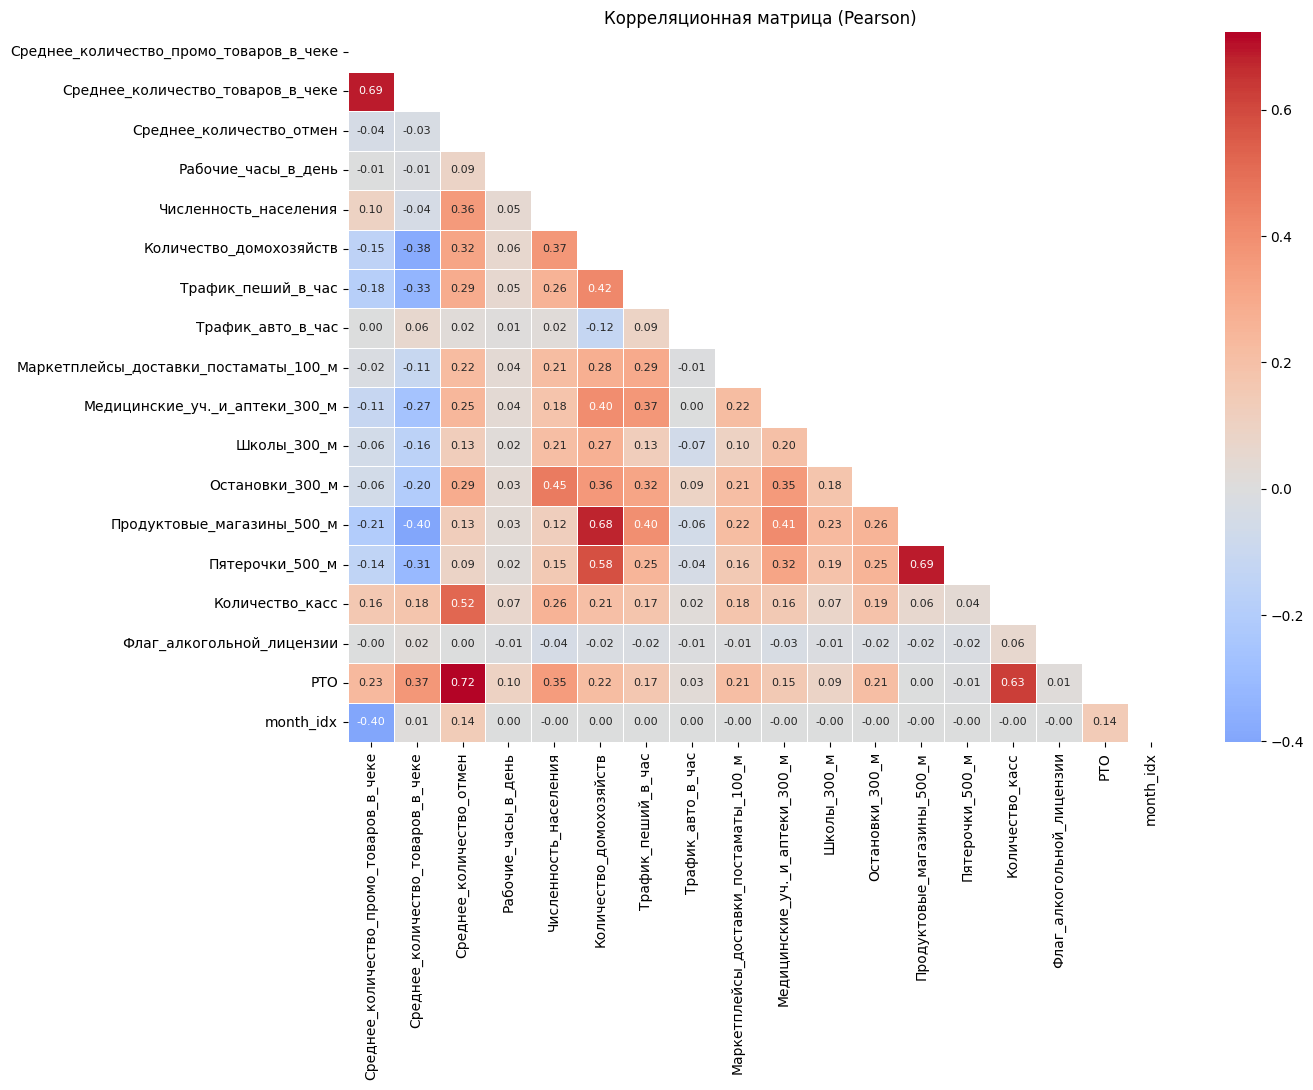


=== Топ-10 корреляций с РТО ===
Среднее_количество_отмен                   0.723
Количество_касс                            0.627
Среднее_количество_товаров_в_чеке          0.369
Численность_населения                      0.351
Среднее_количество_промо_товаров_в_чеке    0.235
Количество_домохозяйств                    0.215
Маркетплейсы_доставки_постаматы_100_м      0.212
Остановки_300_м                            0.212
Трафик_пеший_в_час                         0.167
Медицинские_уч._и_аптеки_300_м             0.154


In [27]:
import seaborn as sns
corr_cols = [c for c in num_cols if c not in ['new_id', 'Год', 'Месяц']]
corr = df_raw[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Корреляционная матрица (Pearson)')
plt.tight_layout()
plt.show()

print("\n=== Топ-10 корреляций с РТО ===")
target_corr = corr['РТО'].drop('РТО').sort_values(key=abs, ascending=False)
print(target_corr.head(10).round(3).to_string())

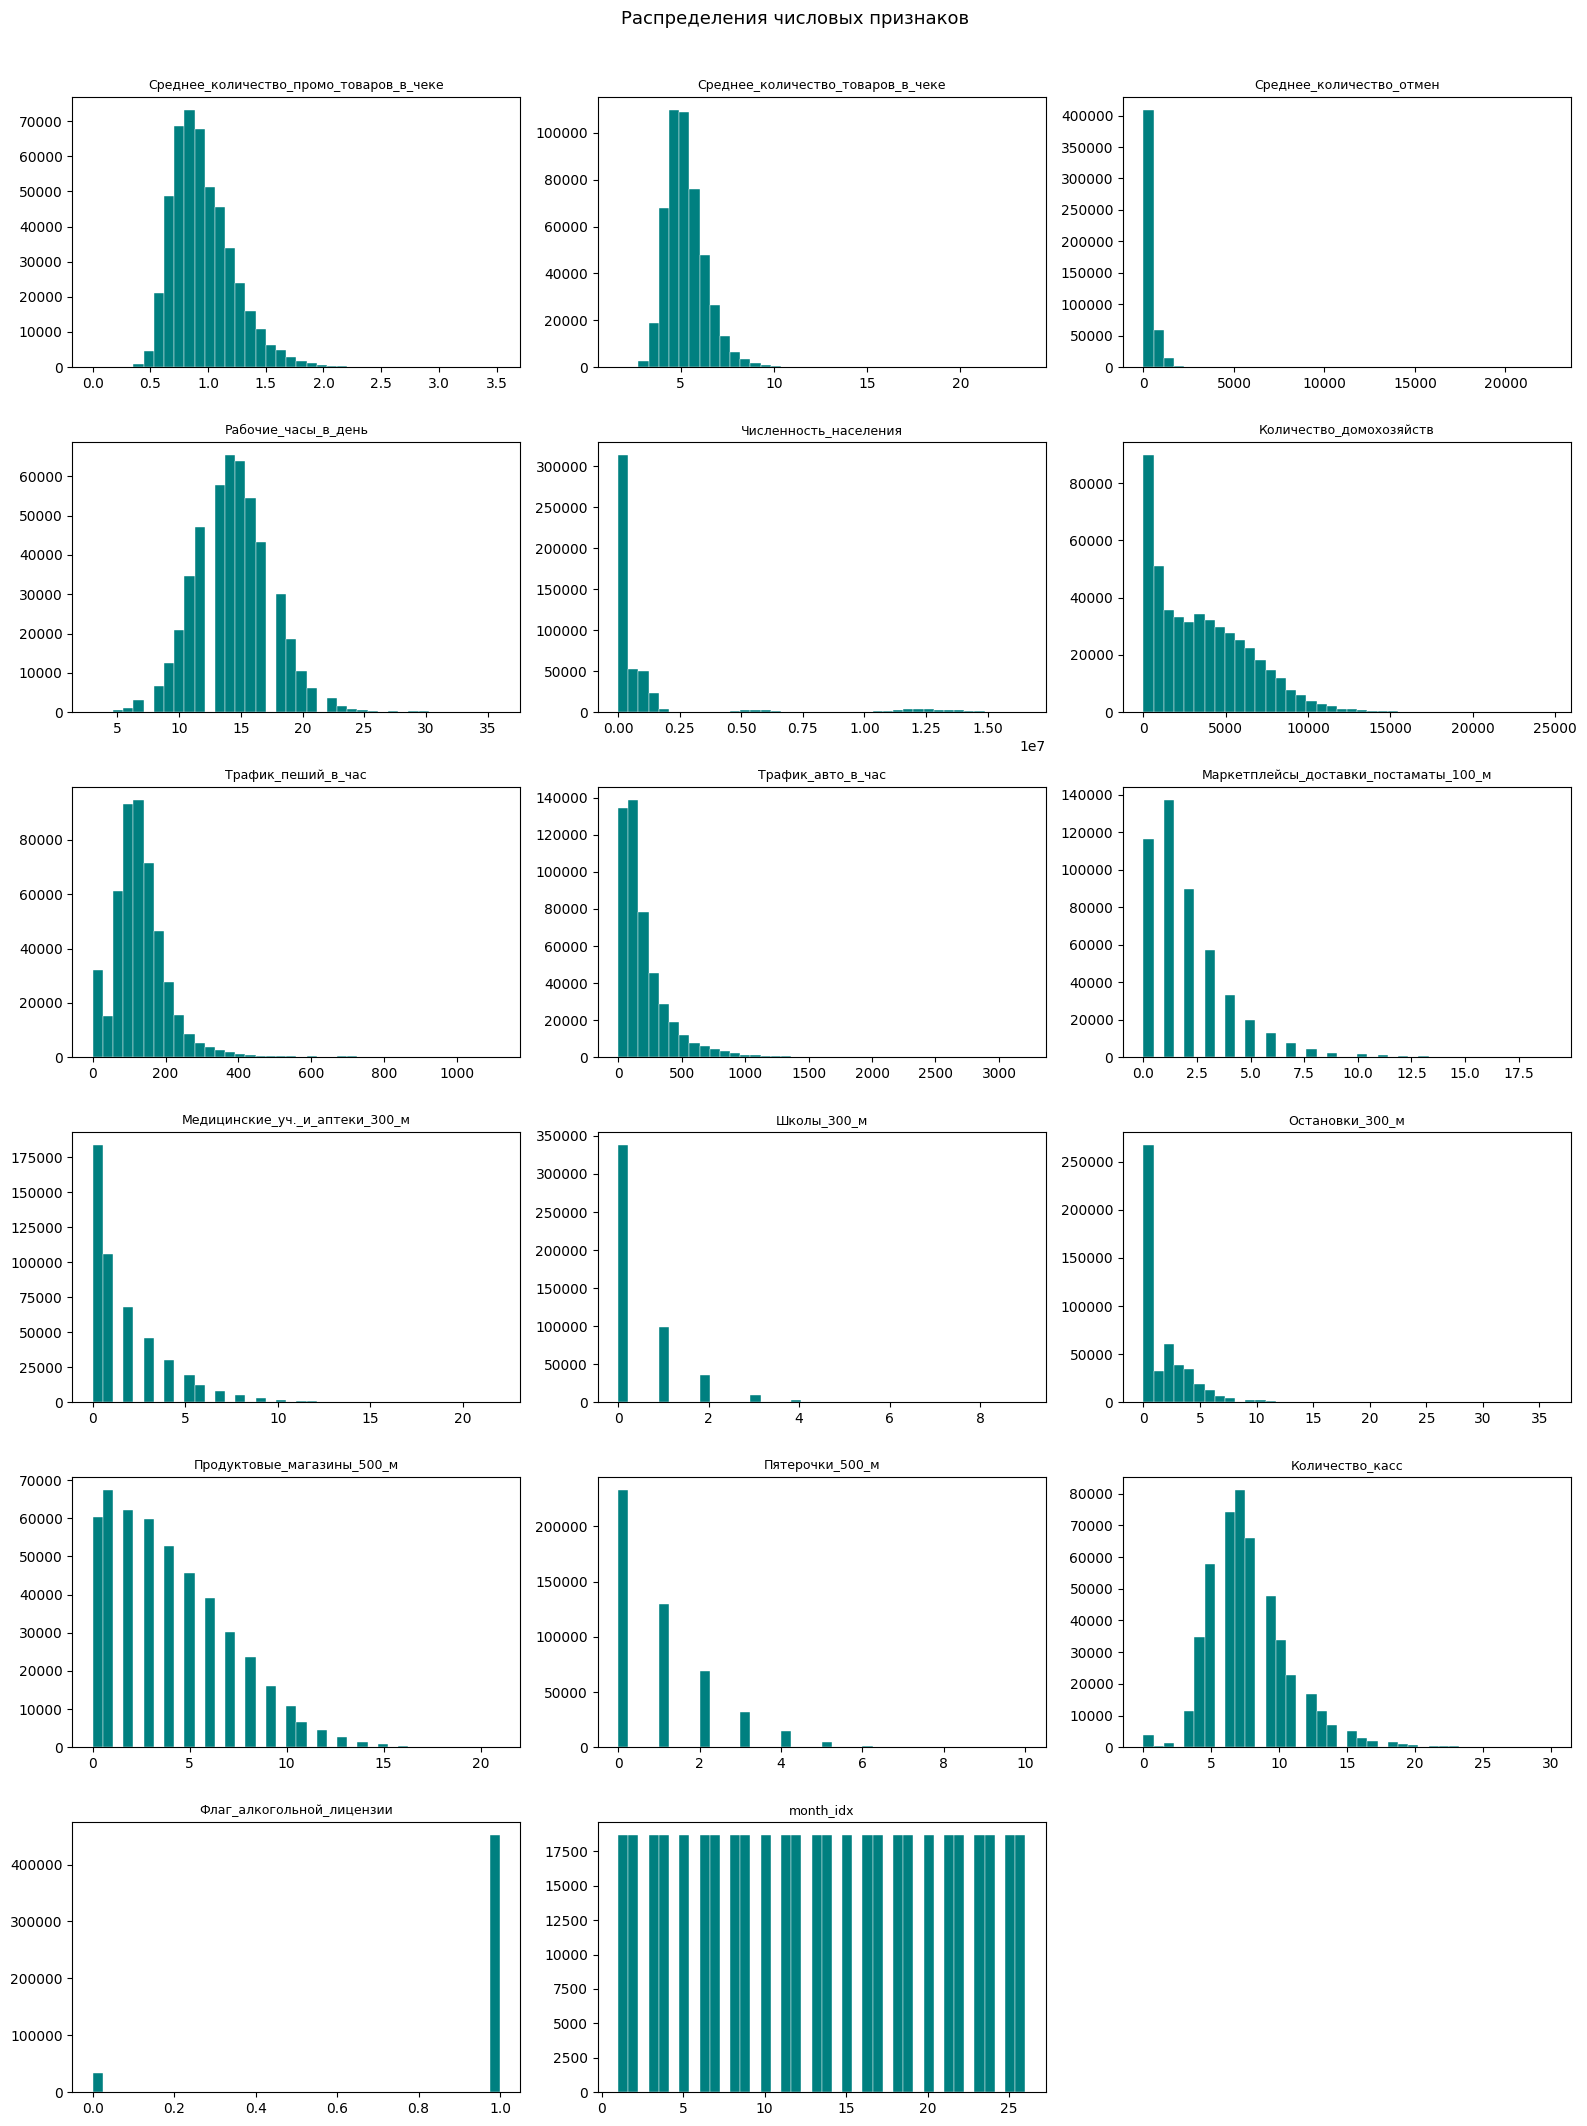

In [28]:
plot_cols = [c for c in num_cols if c not in ['new_id', 'Год', 'Месяц', 'РТО',
                                                'Флаг алкогольной лицензии']]
n = len(plot_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df_raw[col].dropna(), bins=40, color='teal', edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения числовых признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [5]:
print("Очистка и базовая подготовка...")

def clean_feature_names(df):
    df.columns = [re.sub(r'[ \t\n\r\f\v,\"\':\[\]\{\}\(\)]', '_', col) for col in df.columns]
    df.columns = [re.sub(r'_+', '_', col).strip('_') for col in df.columns]
    return df

df_raw = clean_feature_names(df_raw)
df_raw = df_raw.sort_values(by=["new_id", "Год", "Месяц"]).reset_index(drop=True)
df_raw["month_idx"] = (df_raw["Год"] - 2023) * 12 + df_raw["Месяц"]

df_clean = df_raw.copy()
df_clean = df_clean[df_clean["РТО"] > 100000].reset_index(drop=True)
q_low, q_high = df_clean["РТО"].quantile(0.005), df_clean["РТО"].quantile(0.995)
df_clean = df_clean[(df_clean["РТО"] >= q_low) & (df_clean["РТО"] <= q_high)].reset_index(drop=True)

# Тестовый каркас на Март 2025
last_known_state = df_raw.sort_values("month_idx").groupby("new_id").last().reset_index()
march_test = last_known_state.copy()
march_test["Год"] = 2025; march_test["Месяц"] = 3; march_test["month_idx"] = 27; march_test["РТО"] = np.nan

df_full = pd.concat([df_clean, march_test], ignore_index=True).drop_duplicates(subset=["new_id", "month_idx"], keep="last").sort_values(by=["new_id", "month_idx"]).reset_index(drop=True)

Очистка и базовая подготовка...


In [6]:
print("Моделирование мартовского трафика...")
traffic_base_features = ["Численность_населения", "Количество_домохозяйств", "Количество_касс"]

df_full["traffic_ped_lag1"] = df_full.groupby("new_id")["Трафик_пеший_в_час"].shift(1)
df_full["traffic_auto_lag1"] = df_full.groupby("new_id")["Трафик_авто_в_час"].shift(1)

tr_traffic_mask = (df_full["month_idx"] > 1) & (df_full["month_idx"] < 27)
X_traffic_tr = df_full[tr_traffic_mask][traffic_base_features + ["traffic_ped_lag1", "traffic_auto_lag1", "Месяц"]].fillna(0)
y_ped_tr = df_full[tr_traffic_mask]["Трафик_пеший_в_час"]
y_auto_tr = df_full[tr_traffic_mask]["Трафик_авто_в_час"]

model_ped = lgb.LGBMRegressor(n_estimators=250, learning_rate=0.06, random_state=42, verbose=-1, n_jobs=-1)
model_ped.fit(X_traffic_tr, y_ped_tr)

model_auto = lgb.LGBMRegressor(n_estimators=250, learning_rate=0.06, random_state=42, verbose=-1, n_jobs=-1)
model_auto.fit(X_traffic_tr, y_auto_tr)

march_mask = df_full["month_idx"] == 27
X_traffic_ts = df_full[march_mask][traffic_base_features + ["traffic_ped_lag1", "traffic_auto_lag1", "Месяц"]].fillna(0)

df_full.loc[march_mask, "Трафик_пеший_в_час"] = model_ped.predict(X_traffic_ts).astype(int)
df_full.loc[march_mask, "Трафик_авто_в_час"] = model_auto.predict(X_traffic_ts).astype(int)
print("  Векторы мартовского трафика обновлены.")

Моделирование мартовского трафика...
  Векторы мартовского трафика обновлены.


In [7]:
print("Расчет расширенной матрицы признаков...")

# Группа А: Календарь
days_in_months = {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}
df_full["days_in_month"] = df_full["Месяц"].map(days_in_months)
df_full.loc[(df_full["Год"] == 2024) & (df_full["Месяц"] == 2), "days_in_month"] = 29
df_full["is_spring_summer"] = df_full["Месяц"].isin([5, 6, 7, 8]).astype(int)
df_full["is_q4"] = df_full["Месяц"].isin([10, 11, 12]).astype(int)

# Группа Б: Хронологические лаги внутренней среды
dynamic_cols = ["РТО", "Среднее_количество_промо_товаров_в_чеке", "Среднее_количество_товаров_в_чеке",
                "Среднее_количество_отмен", "Рабочие_часы_в_день", "Трафик_пеший_в_час", "Трафик_авто_в_час"]
for col in dynamic_cols:
    df_full[f"{col}_lag_1"] = df_full.groupby("new_id")[col].shift(1)
    df_full[f"{col}_lag_2"] = df_full.groupby("new_id")[col].shift(2)
    df_full[f"{col}_lag_3"] = df_full.groupby("new_id")[col].shift(3)
    df_full[f"{col}_lag_12"] = df_full.groupby("new_id")[col].shift(12)

# Группа В: Тренды скоростей (MoM, YoY)
df_full["rto_speed_mom"] = (df_full["РТО_lag_1"] / (df_full["РТО_lag_2"] + 1)).fillna(1.0)
df_full["rto_speed_mom_long"] = (df_full["РТО_lag_1"] / (df_full["РТО_lag_3"] + 1)).fillna(1.0)
df_full["rto_yoy_ratio"] = (df_full["РТО_lag_1"] / (df_full["РТО_lag_12"] + 1)).fillna(1.0)
df_full["traffic_ped_yoy_ratio"] = (df_full["Трафик_пеший_в_час_lag_1"] / (df_full["Трафик_пеший_в_час_lag_12"] + 1)).fillna(1.0)

# Группа Г: Геостатика и локация
df_full["local_household_size"] = df_full["Численность_населения"] / (df_full["Количество_домохозяйств"] + 1)
df_full["market_capacity_per_cashbox"] = df_full["Количество_домохозяйств"] / (df_full["Количество_касс"] + 1)
df_full["infrastructure_density"] = df_full["Остановки_300_м"] + df_full["Медицинские_уч._и_аптеки_300_м"] + df_full["Школы_300_м"]
df_full["pedestrian_auto_ratio"] = df_full["Трафик_пеший_в_час_lag_1"] / (df_full["Трафик_авто_в_час_lag_1"] + 1)

# Группа Д: Конкурентное окружение и давление e-com
df_full["competitor_pressure"] = df_full["Пятерочки_500_м"] / (df_full["Продуктовые_магазины_500_м"] + 1)
df_full["ecom_pressure_index"] = df_full["Маркетплейсы_доставки_постаматы_100_м"] / (df_full["Трафик_пеший_в_час_lag_1"] + 1)

# Группа Е: Эффективность единицы мощностей
df_full["rto_per_cashbox_lag_1"] = df_full["РТО_lag_1"] / (df_full["Количество_касс"] + 1)
df_full["cancel_rate_lag_1"] = df_full["Среднее_количество_отмен_lag_1"] / (df_full["Среднее_количество_товаров_в_чеке_lag_1"] + 1)
df_full["promo_ratio_lag_1"] = df_full["Среднее_количество_промо_товаров_в_чеке_lag_1"] / (df_full["Среднее_количество_товаров_в_чеке_lag_1"] + 1)

# Группа Ж: Сетевые макроиндексы рынка
network_monthly_mean = df_full.groupby("month_idx")["РТО_lag_1"].transform("mean")
df_full["network_macro_trend"] = network_monthly_mean / (df_full[df_full["month_idx"] == 13]["РТО_lag_1"].mean() + 1)
region_monthly_mean = df_full.groupby(["Регион", "month_idx"])["РТО_lag_1"].transform("mean")
df_full["region_macro_trend"] = region_monthly_mean / (network_monthly_mean + 1)

df_full["is_new_store"] = df_full["РТО_lag_12"].isnull().astype(int)

# Таргет — отношение текущего РТО к РТО прошлого месяца
df_full["target_ratio"] = df_full["РТО"] / (df_full["РТО_lag_1"] + 1)
df_full["target_ratio"] = df_full["target_ratio"].replace([np.inf, -np.inf], np.nan)

df_features = df_full[df_full["month_idx"] > 12].reset_index(drop=True)

bad_rows_mask = (df_features["target_ratio"].isna()) & (df_features["month_idx"] <= 26)
df_features = df_features[~bad_rows_mask].reset_index(drop=True)

cat_cols = ["Дата_открытия_категориальный", "Торговая_площадь_категориальный", "Населенный_пункт", "Регион"]
for col in cat_cols:
    df_features[col] = df_features[col].astype("category")

features = [col for col in df_features.columns if col not in dynamic_cols + ["month_idx", "target_ratio", "traffic_ped_lag1", "traffic_auto_lag1"]]

for col in features:
    if df_features[col].dtype not in ['category', 'object']:
        df_features[col] = df_features[col].replace([np.inf, -np.inf], np.nan)
        if df_features[col].isna().sum() > 0:
            df_features[col] = df_features[col].fillna(df_features[col].median() if not pd.isna(df_features[col].median()) else 0)

Расчет расширенной матрицы признаков...


In [8]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [9]:
import catboost as cb

# Гиперпараметры каждой модели рассчитаны через Optuna
xgb_params = {
    "n_estimators": 1200,
    "learning_rate": 0.04,
    "max_depth": 7,
    "subsample": 0.6,
    "colsample_bytree": 0.5,
    "min_child_weight": 7,
    "reg_alpha": 0.006894567462203253,
    "reg_lambda": 0.006793677307400017,
    "tree_method": "hist",
    "enable_categorical": True,
    "objective": "reg:absoluteerror",
    "random_state": 42
}

lgb_params = {
    "n_estimators": 1800,
    "learning_rate": 0.04,
    "num_leaves": 90,
    "max_depth": 7,
    "min_child_samples": 50,
    "subsample": 0.6,
    "colsample_bytree": 0.5,
    "reg_alpha": 0.4440355962956742,
    "reg_lambda": 0.44864909333368413,
    "objective": "regression_l1",
    "random_state": 42
}

cb_params = {
    "iterations": 1500,
    "learning_rate": 0.04,
    "depth": 5,
    "l2_leaf_reg": 4.0,
    "min_data_in_leaf": 20,
    "loss_function": "MAE",
    "eval_metric": "MAPE",
    "random_seed": 42,
    "verbose": False
}

val_months = [24, 25, 26]
month_names = {24: "Декабрь 2024", 25: "Январь 2025", 26: "Февраль 2025"}

# Списки для накопления мета-признаков
meta_train_features = []
meta_train_target = []
meta_train_lag_rto = []
meta_train_weights = []

TOP_STORE_THRESHOLD = 5000000
TOP_MULTIPLIER = 1.02

print("\n" + "="*95)
print("--СТАРТ ТРЕХМОДЕЛЬНОГО СТЕКИНГА--")
print("="*95)

for i, v_month in enumerate(val_months, 1):
    train_mask = (df_features["month_idx"] >= 13) & (df_features["month_idx"] <= (v_month - 1))
    val_mask = df_features["month_idx"] == v_month

    X_tr = df_features[train_mask][features].copy()
    y_tr_ratio = df_features[train_mask]["target_ratio"]

    X_v = df_features[val_mask][features].copy()
    y_v_real = df_features[val_mask]["РТО"]
    v_lag = df_features[val_mask]["РТО_lag_1"]

    # Веса строк для обучения базовых моделей внутри фолда
    s_weights = np.exp((df_features[train_mask]["month_idx"] - df_features[train_mask]["month_idx"].max()) / 12)

    # 1. XGBoost
    m_xgb = xgb.XGBRegressor(**xgb_params)
    m_xgb.fit(X_tr, y_tr_ratio, sample_weight=s_weights, verbose=False)
    p_rto_xgb = m_xgb.predict(X_v) * (v_lag + 1)

    # 2. LightGBM
    m_lgb = lgb.LGBMRegressor(**lgb_params)
    m_lgb.fit(X_tr, y_tr_ratio, sample_weight=s_weights)
    p_rto_lgb = m_lgb.predict(X_v) * (v_lag + 1)

    # 3. CatBoost
    X_tr_cb, X_v_cb = X_tr.copy(), X_v.copy()
    for c in cat_cols:
        X_tr_cb[c] = X_tr_cb[c].astype(str)
        X_v_cb[c] = X_v_cb[c].astype(str)

    m_cb = cb.CatBoostRegressor(**cb_params)
    m_cb.fit(X_tr_cb, y_tr_ratio, cat_features=cat_cols, sample_weight=s_weights)
    p_rto_cb = m_cb.predict(X_v_cb) * (v_lag + 1)

    # Логируем базовые модели
    m_xgb_mape = mean_absolute_percentage_error(y_v_real, p_rto_xgb) * 100
    m_lgb_mape = mean_absolute_percentage_error(y_v_real, p_rto_lgb) * 100
    m_cb_mape = mean_absolute_percentage_error(y_v_real, p_rto_cb) * 100

    print(f"\n[Фолд {i}/3] Период: {month_names[v_month]}")
    print(f"  • Базовый MAPE: XGB = {m_xgb_mape:.3f}% | LGB = {m_lgb_mape:.3f}% | CatBoost = {m_cb_mape:.3f}%")

    # Собираем прогнозы
    fold_meta = pd.DataFrame({
        "pred_xgb": p_rto_xgb,
        "pred_lgb": p_rto_lgb,
        "pred_cb": p_rto_cb,
        "lag_size": np.log1p(v_lag),
        "pred_std": np.std([p_rto_xgb, p_rto_lgb, p_rto_cb], axis=0)
    })
    meta_train_features.append(fold_meta)
    meta_train_target.append(y_v_real.values)
    meta_train_lag_rto.append(v_lag.values)

    avg_mape = (m_xgb_mape + m_lgb_mape + m_cb_mape) / 3
    fold_weight = 1.0 / max(avg_mape, 0.01)
    meta_train_weights.append(np.full(shape=len(y_v_real), fill_value=fold_weight))

X_meta_train = pd.concat(meta_train_features, ignore_index=True)
y_meta_train = np.concatenate(meta_train_target)
lag_meta_train = np.concatenate(meta_train_lag_rto)
w_meta_train = np.concatenate(meta_train_weights)


--СТАРТ ТРЕХМОДЕЛЬНОГО СТЕКИНГА--

[Фолд 1/3] Период: Декабрь 2024
  • Базовый MAPE: XGB = 10.451% | LGB = 10.316% | CatBoost = 9.945%

[Фолд 2/3] Период: Январь 2025
  • Базовый MAPE: XGB = 3.839% | LGB = 3.891% | CatBoost = 4.168%

[Фолд 3/3] Период: Февраль 2025
  • Базовый MAPE: XGB = 4.000% | LGB = 4.172% | CatBoost = 4.584%


In [18]:
print("\n" + "="*50)
print("Обучение раздельных мета-моделей по кластерам...")

from sklearn.preprocessing import StandardScaler

low_threshold = np.percentile(lag_meta_train, 33)  # Нижняя треть
high_threshold = np.percentile(lag_meta_train, 67)  # Верхняя треть

# Определяем маски кластеров для OOF-выборки
cluster_masks= {
    f"Малые магазины (< {low_threshold:,.0f})": lag_meta_train <= low_threshold,
    f"Средние магазины ({low_threshold:,.0f} - {high_threshold:,.0f})": (lag_meta_train > low_threshold) & (lag_meta_train <= high_threshold),
    f"Крупные магазины (> {high_threshold:,.0f})": lag_meta_train > high_threshold
}

meta_models = {}
meta_preds_final = np.zeros_like(y_meta_train)

# Нормализация данных для HuberRegressor
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta_train)

# Обучаем HuberRegressor на масштабированных данных
for c_name, mask in cluster_masks.items():
    if np.sum(mask) > 0:
        model = HuberRegressor(epsilon=1.35, max_iter=1000)
        model.fit(X_meta_scaled[mask], y_meta_train[mask], sample_weight=w_meta_train[mask])
        meta_models[c_name] = model
        meta_preds_final[mask] = model.predict(X_meta_scaled[mask])

print("-" * 75)
print(f"{'Кластер магазинов (по РТО_lag_1)':<35} | {'Стратегия':<12} | {'Итоговый MAPE':<10}")
print("-" * 75)

for c_name, mask in cluster_masks.items():
    if np.sum(mask) > 0:
        mape_cluster = mean_absolute_percentage_error(y_meta_train[mask], meta_preds_final[mask]) * 100
        print(f"{c_name:<35} | {'Auto-Huber':<12} | {mape_cluster:.3f}%")
    else:
        print(f"{c_name:<35} | {'Auto-Huber':<12} | {'Нет дан.':<10}")
print("-" * 75)

global_post_mape = mean_absolute_percentage_error(y_meta_train, meta_preds_final) * 100
print(f">>> Глобальный MAPE кластерного стекинга: {global_post_mape:.3f}%")
print("="*50)


Обучение раздельных мета-моделей по кластерам...
---------------------------------------------------------------------------
Кластер магазинов (по РТО_lag_1)    | Стратегия    | Итоговый MAPE
---------------------------------------------------------------------------
Малые магазины (< 69,702,321)       | Auto-Huber   | 7.426%
Средние магазины (69,702,321 - 103,179,529) | Auto-Huber   | 6.551%
Крупные магазины (> 103,179,529)    | Auto-Huber   | 5.321%
---------------------------------------------------------------------------
>>> Глобальный MAPE кластерного стекинга: 6.434%


In [19]:
print("\n" + "="*50)
print("Переобучение базовых моделей...")
print("="*50)

# Берем все доступные данные (с 13 по 26 месяц)
final_train_mask = (df_features["month_idx"] >= 13) & (df_features["month_idx"] <= 26)
X_final = df_features[final_train_mask][features].copy()
y_final_ratio = df_features[final_train_mask]["target_ratio"]

# Веса для финального обучения (свежие месяцы важнее)
final_weights = np.exp((df_features[final_train_mask]["month_idx"] - 26) / 12)

print(f"Обучаем XGBoost на {len(X_final)} строках...")
final_xgb = xgb.XGBRegressor(**xgb_params)
final_xgb.fit(X_final, y_final_ratio, sample_weight=final_weights, verbose=False)

print(f"Обучаем LightGBM на {len(X_final)} строках...")
final_lgb = lgb.LGBMRegressor(**lgb_params)
final_lgb.fit(X_final, y_final_ratio, sample_weight=final_weights)

print(f"Обучаем CatBoost на {len(X_final)} строках...")
X_final_cb = X_final.copy()
for c in cat_cols:
    X_final_cb[c] = X_final_cb[c].astype(str)
final_cb = cb.CatBoostRegressor(**cb_params)
final_cb.fit(X_final_cb, y_final_ratio, cat_features=cat_cols, sample_weight=final_weights)

print("Базовые модели переобучены!\n")


Переобучение базовых моделей...
Обучаем XGBoost на 258836 строках...
Обучаем LightGBM на 258836 строках...
Обучаем CatBoost на 258836 строках...
Базовые модели переобучены!



In [20]:
print("\nГенерация мартовского прогноза на основе кластеров...")

X_test = df_features[df_features["month_idx"] == 27][features].copy()
test_lag = df_features[df_features["month_idx"] == 27]["РТО_lag_1"]

# Прогнозы базовых моделей
print("Генерируем прогнозы базовых моделей...")
march_ratio_xgb = final_xgb.predict(X_test)
march_ratio_lgb = final_lgb.predict(X_test)

X_test_cb = X_test.copy()
for c in cat_cols:
    X_test_cb[c] = X_test_cb[c].astype(str)
march_ratio_cb = final_cb.predict(X_test_cb)

# Перевод в рубли
march_rto_xgb = march_ratio_xgb * (test_lag + 1)
march_rto_lgb = march_ratio_lgb * (test_lag + 1)
march_rto_cb = march_ratio_cb * (test_lag + 1)

# Мета-признаки для теста
X_meta_test = pd.DataFrame({
    "pred_xgb": march_rto_xgb,
    "pred_lgb": march_rto_lgb,
    "pred_cb": march_rto_cb
})

if 'low_threshold' not in dir():
    low_threshold = np.percentile(test_lag, 33)
    high_threshold = np.percentile(test_lag, 67)
    print(f"Внимание: используются границы на основе теста: {low_threshold:.0f}, {high_threshold:.0f}")
else:
    print(f"Используем границы из обучения: low={low_threshold:.0f}, high={high_threshold:.0f}")

# Распределяем мартовские магазины по тем же кластерам
test_masks = {
    f"Малые магазины (< {low_threshold:.0f})": test_lag <= low_threshold,
    f"Средние магазины ({low_threshold:.0f} - {high_threshold:.0f})": (test_lag > low_threshold) & (test_lag <= high_threshold),
    f"Крупные магазины (> {high_threshold:.0f})": test_lag > high_threshold
}

# Финальный вектор предсказаний теста
final_march_preds = np.zeros(len(X_test))

print("\nПрогнозирование по кластерам:")
for c_name, mask in test_masks.items():
    n_stores = np.sum(mask)
    if n_stores > 0:
        if c_name in meta_models:
            final_march_preds[mask] = meta_models[c_name].predict(X_meta_test[mask])
        else:
            final_march_preds[mask] = X_meta_test[mask].mean(axis=1)
    else:
        print(f"  • {c_name}: нет магазинов")

# Сохранение итогового файла
print("\nСохранение результатов...")
submission = pd.DataFrame({
    "new_id": X_test["new_id"].values,
    "rto": final_march_preds
}).sort_values(by="new_id").reset_index(drop=True)

# Проверка на наличие аномалий
print(f"\nСтатистика прогнозов:")
print(f"  • Среднее: {final_march_preds.mean():.2f}")
print(f"  • Медиана: {np.median(final_march_preds):.2f}")
print(f"  • Мин: {final_march_preds.min():.2f}")
print(f"  • Макс: {final_march_preds.max():.2f}")
print(f"  • Стандартное отклонение: {final_march_preds.std():.2f}")

submission.to_csv("test.csv", index=False)
print("\nИтоговый файл 'test.csv' успешно записан.")


Генерация мартовского прогноза на основе кластеров...
Генерируем прогнозы базовых моделей...
Используем границы из обучения: low=69702321, high=103179529

Прогнозирование по кластерам:

Сохранение результатов...

Статистика прогнозов:
  • Среднее: 99054427.83
  • Медиана: 84676691.87
  • Мин: 29579796.38
  • Макс: 330703901.32
  • Стандартное отклонение: 51407781.27

Итоговый файл 'test.csv' успешно записан.
